In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, log_loss
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.benchmark as benchmark
import torch._dynamo
from torchinfo import summary
import seaborn as sns

In [2]:
torch._dynamo.config.cache_size_limit = 16

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device = "cpu"

In [3]:
df = sns.load_dataset('diamonds')
df = df[['carat', 'depth', 'table', 'price', 'x', 'y', 'z', 'cut']]

df['cut'] = (df['cut'] == 'Ideal').astype(int)

X = df.drop('cut', axis=1)
y = df['cut']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long).to(device)

print(X.shape)
print(y.shape)

(53940, 7)
(53940,)


In [4]:
def train(model, criterion, optimizer):
    print(summary(model, input_data=X_train_tensor))

    torch.set_printoptions(threshold=float('inf'))
    for name, param in model.named_parameters():
        print(name)
        print(param)

    @torch._dynamo.explain
    def run_model(x):
        return model(x)

    run_model(X_train_tensor) # type: ignore

    epochs = 10000
    best_test_loss = float('inf')

    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        train_outputs = model(X_train_tensor)
        train_loss = criterion(train_outputs, y_train_tensor)
        train_loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test_tensor)
            test_loss = criterion(test_outputs, y_test_tensor)
            test_predictions = torch.argmax(test_outputs, dim=1)
            test_accuracy = (test_predictions == y_test_tensor).sum().item() / y_test_tensor.size(0)

        train_losses.append(train_loss.item())
        test_losses.append(test_loss.item())

        if test_loss.item() < best_test_loss:
            best_test_loss = test_loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss.item():.8f}, Test Loss: {test_loss.item():.8f}, Test Accuracy: {test_accuracy:.4f}")

    print()
    print(f"Lowest Test Loss: {best_test_loss:.8f}")

    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Test Loss Over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()

In [10]:
class DiamondNN(nn.Module):
    def __init__(self, n, num_layers=4):
        super().__init__()
        self.layers = nn.ModuleList()

        for i in range(num_layers):
            dim = n * (2**i)
            layer = nn.Linear(dim, dim)

            with torch.no_grad():
                layer.weight.copy_(torch.eye(dim))
                nn.init.zeros_(layer.bias)
            
            self.layers.append(layer)

        self.final = nn.Linear(n * (2**num_layers), 1)
        nn.init.zeros_(self.final.weight)
        nn.init.zeros_(self.final.bias)

    def forward(self, x):
        out = x
        features = [out]

        for layer in self.layers:
            x_cat = torch.cat(features, dim=-1)
            out = F.layer_norm(layer(x_cat), x_cat.shape[-1:])
            features.append(out)

        final_input = torch.cat(features, dim=-1)
        output = self.final(final_input)
        return torch.cat([output, -output], dim=-1)


In [11]:
model = torch.compile(DiamondNN(n=X.shape[1]).to(device))
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─DiamondNN: 1-1                         [43152, 2]                --
│    └─ModuleList: 2-1                   --                        --
│    │    └─Linear: 3-1                  [43152, 7]                56
│    │    └─Linear: 3-2                  [43152, 14]               210
│    │    └─Linear: 3-3                  [43152, 28]               812
│    │    └─Linear: 3-4                  [43152, 56]               3,192
│    └─Linear: 2-2                       [43152, 1]                113
Total params: 4,383
Trainable params: 4,383
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 189.14
Input size (MB): 1.21
Forward/backward pass size (MB): 36.59
Params size (MB): 0.02
Estimated Total Size (MB): 37.82
_orig_mod.layers.0.weight
Parameter containing:
tensor([[1., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0.],
        

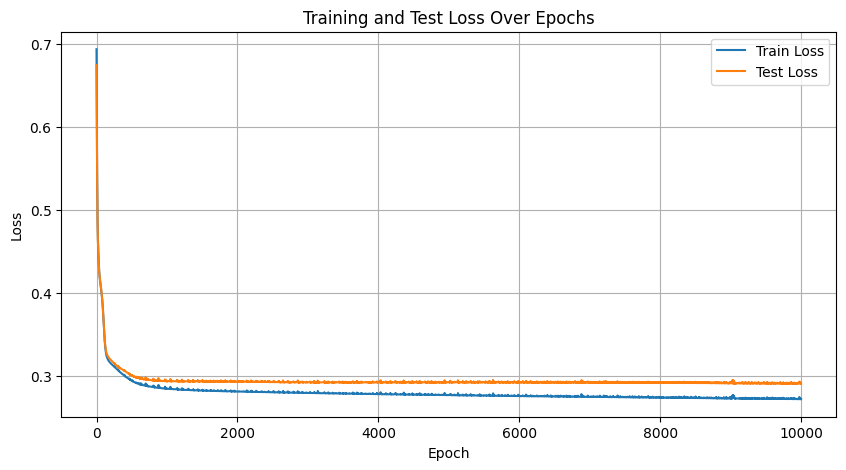

In [12]:
train(model, criterion, optimizer)

In [31]:
class DiamondNN(nn.Module):
    def __init__(self, n, num_layers=2):
        super().__init__()
        self.bias = torch.nn.Parameter(torch.zeros(n))

        self.bns = nn.ModuleList()
        self.linears = nn.ModuleList()
        for i in range(num_layers):
            dim = n * (2**i)
            self.bns.append(nn.BatchNorm1d(dim * 2, affine=False))
            self.linears.append(nn.Linear(dim * 2, dim))

            with torch.no_grad():
                self.linears[i].weight.copy_(torch.eye(dim).repeat_interleave(2, dim=1)) # type: ignore
                nn.init.zeros_(self.linears[i].bias)                                     # type: ignore

        self.final_bn = nn.BatchNorm1d(2 * n * (2**num_layers), affine=False)
        self.final = nn.Linear((2 * n) * (2**num_layers), 1)

        with torch.no_grad():
            nn.init.zeros_(self.final.weight)
            nn.init.zeros_(self.final.bias)

    def forward(self, x):
        x = x + self.bias
        pos = F.relu(x)
        neg = -F.relu(-x)
        x = torch.cat([pos, neg], dim=-1)

        for linear, bn in zip(self.linears, self.bns):
            out = linear(bn(x))
            pos = F.relu(out)
            neg = -F.relu(-out)
            x = torch.cat([x, pos, neg], dim=-1)

        x = self.final(self.final_bn(x))
        return torch.cat([x, -x], dim=-1)

In [32]:
model = torch.compile(DiamondNN(n=X.shape[1]).to(device))
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─DiamondNN: 1-1                         [43152, 2]                7
│    └─ModuleList: 2-3                   --                        --
│    │    └─BatchNorm1d: 3-1             [43152, 14]               --
│    └─ModuleList: 2-4                   --                        (recursive)
│    │    └─Linear: 3-2                  [43152, 7]                105
│    └─ModuleList: 2-3                   --                        --
│    │    └─BatchNorm1d: 3-3             [43152, 28]               --
│    └─ModuleList: 2-4                   --                        (recursive)
│    │    └─Linear: 3-4                  [43152, 14]               406
│    └─BatchNorm1d: 2-5                  [43152, 56]               --
│    └─Linear: 2-6                       [43152, 1]                57
Total params: 575
Trainable params: 575
Non-trainable params: 0
To

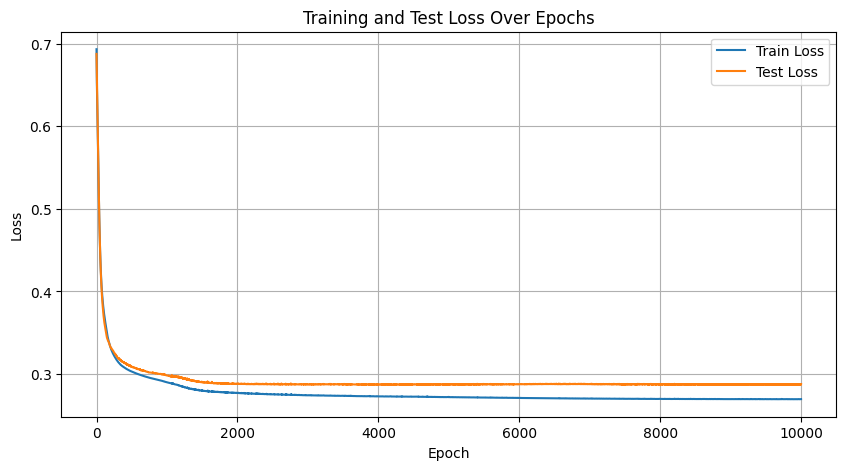

In [33]:
train(model, criterion, optimizer)

In [30]:
train(model, criterion, optimizer)

Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─DiamondNN: 1-1                         [43152, 2]                7
│    └─ModuleList: 2-3                   --                        (recursive)
│    │    └─BatchNorm1d: 3-1             [43152, 14]               28
│    └─ModuleList: 2-4                   --                        (recursive)
│    │    └─Linear: 3-2                  [43152, 7]                105
│    └─ModuleList: 2-3                   --                        (recursive)
│    │    └─BatchNorm1d: 3-3             [43152, 28]               56
│    └─ModuleList: 2-4                   --                        (recursive)
│    │    └─Linear: 3-4                  [43152, 14]               406
│    └─BatchNorm1d: 2-5                  [43152, 56]               112
│    └─Linear: 2-6                       [43152, 1]                57
Total params: 771
Trainable params: 771
Non-tra

KeyboardInterrupt: 

Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─DiamondNN: 1-1                         [43152, 2]                7
│    └─ModuleList: 2-3                   --                        (recursive)
│    │    └─BatchNorm1d: 3-1             [43152, 14]               28
│    └─ModuleList: 2-4                   --                        (recursive)
│    │    └─Linear: 3-2                  [43152, 7]                105
│    └─ModuleList: 2-3                   --                        (recursive)
│    │    └─BatchNorm1d: 3-3             [43152, 28]               56
│    └─ModuleList: 2-4                   --                        (recursive)
│    │    └─Linear: 3-4                  [43152, 14]               406
│    └─Linear: 2-5                       [43152, 1]                57
Total params: 659
Trainable params: 659
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 28.14
Input size (M

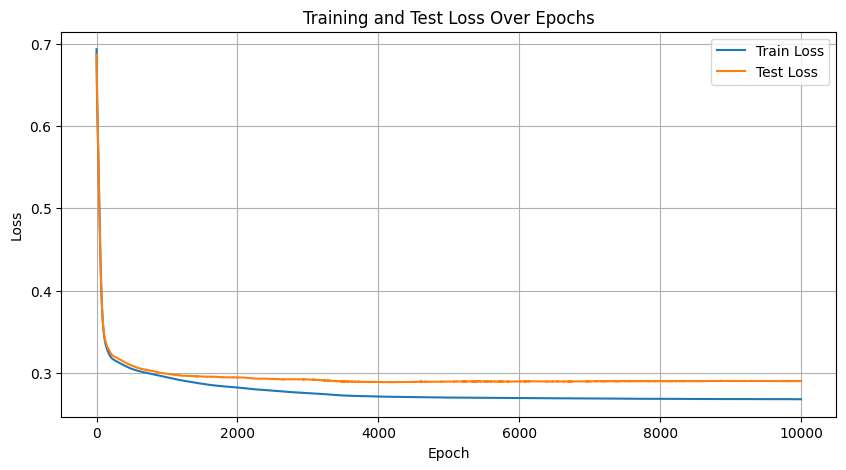

In [27]:
train(model, criterion, optimizer)

Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─DiamondNN: 1-1                         [43152, 2]                7
│    └─ModuleList: 2-3                   --                        (recursive)
│    │    └─Linear: 3-1                  [43152, 7]                105
│    └─ModuleList: 2-4                   --                        (recursive)
│    │    └─BatchNorm1d: 3-2             [43152, 7]                14
│    └─ModuleList: 2-3                   --                        (recursive)
│    │    └─Linear: 3-3                  [43152, 14]               406
│    └─ModuleList: 2-4                   --                        (recursive)
│    │    └─BatchNorm1d: 3-4             [43152, 14]               28
│    └─Linear: 2-5                       [43152, 1]                57
Total params: 617
Trainable params: 617
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 26.32
Input size (M

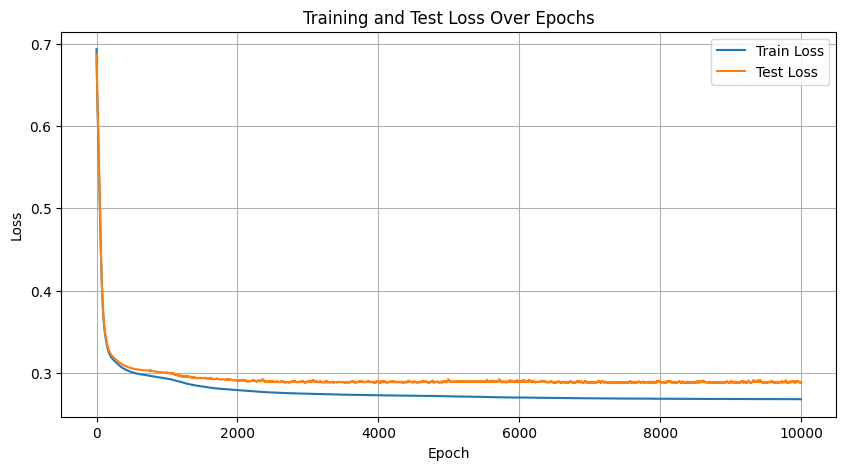

In [18]:
train(model, criterion, optimizer)

In [19]:
class DiamondNN(nn.Module):
    def __init__(self, n, num_layers=2):
        super().__init__()
        self.bias = torch.nn.Parameter(torch.zeros(n))

        self.linears = nn.ModuleList()
        for i in range(num_layers):
            dim = n * (2**i)
            self.linears.append(nn.Linear(dim * 2, dim))

            with torch.no_grad():
                self.linears[i].weight.copy_(torch.eye(dim).repeat_interleave(2, dim=1)) # type: ignore
                nn.init.zeros_(self.linears[i].bias)                                     # type: ignore

        self.final = nn.Linear((2 * n) * (2**num_layers), 1)

        with torch.no_grad():
            nn.init.zeros_(self.final.weight)
            nn.init.zeros_(self.final.bias)

    def forward(self, x):
        x = x + self.bias
        pos = F.relu(x)
        neg = -F.relu(-x)
        x = torch.cat([pos, neg], dim=-1)

        for linear in self.linears:
            out = linear(x)
            out = F.layer_norm(out, out.shape[-1:])
            pos = F.relu(out)
            neg = -F.relu(-out)
            x = torch.cat([x, pos, neg], dim=-1)

        x = self.final(x)
        return torch.cat([x, -x], dim=-1)

In [20]:
model = torch.compile(DiamondNN(n=X.shape[1]).to(device))
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─DiamondNN: 1-1                         [43152, 2]                7
│    └─ModuleList: 2-1                   --                        --
│    │    └─Linear: 3-1                  [43152, 7]                105
│    │    └─Linear: 3-2                  [43152, 14]               406
│    └─Linear: 2-2                       [43152, 1]                57
Total params: 575
Trainable params: 575
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 24.51
Input size (MB): 1.21
Forward/backward pass size (MB): 7.59
Params size (MB): 0.00
Estimated Total Size (MB): 8.81
_orig_mod.bias
Parameter containing:
tensor([0., 0., 0., 0., 0., 0., 0.], requires_grad=True)
_orig_mod.linears.0.weight
Parameter containing:
tensor([[1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [

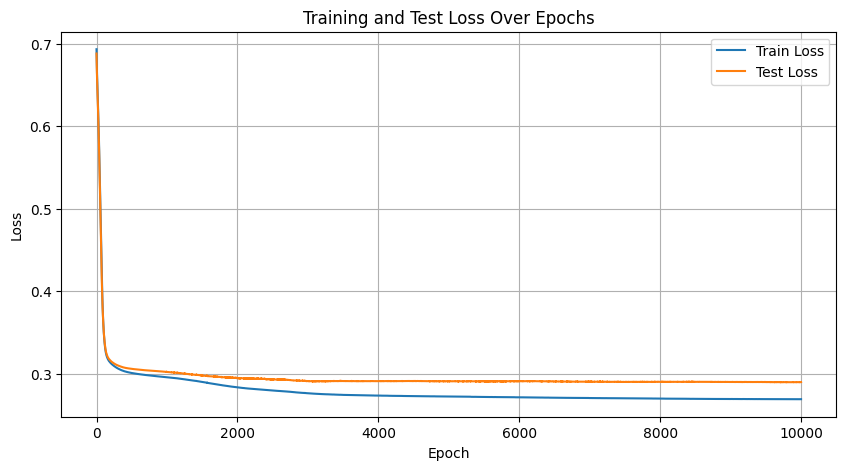

In [21]:
train(model, criterion, optimizer)